# MS-ConvGRU v3 — Multi-Scale Conv1D-GRU with Dual Attention

**Changes from v1:**
- MixUp augmentation added (lambda ~ Beta(0.2, 0.2))
- Center Loss (weight=0.01) for tighter feature clustering
- 80 epochs (from 60)
- Pre-GRU CNN features for calibration (128-dim, more generalizable)
- Prototype Network dropped (LogReg only — consistently better)

## Imports

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

from config import (
    RANDOM_SEED, N_CLASSES, N_CHANNELS, WINDOW_SIZE,
    MODELS_DIR, FIGURES_DIR, get_device,
    SUBJECTS_FATIGUE, SUBJECTS_NON_FATIGUE,
    SUBJECTS_INTERDAY_LONG, SUBJECTS_INTERDAY_SHORT,
    GESTURE_CLASSES,
)
from src.experiment_runner import (
    TEST_SUBJECTS, TRAIN_SUBJECTS, META, get_splits,
    load_and_norm, run_zero_shot, run_calibration, print_comparison,
)
from src.evaluation import measure_latency, print_latency

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = get_device()
print(f"Device: {DEVICE}")
print(f"Train subjects: {TRAIN_SUBJECTS}")
print(f"Test subjects:  {TEST_SUBJECTS}")

Device: mps
Train subjects: ['h0', 'h1', 'h10', 'h11', 'h12', 'h13', 'h14', 'h15', 'h18', 'h19', 'h2', 'h20', 'h21', 'h23', 'h25', 'h26', 'h27', 'h28', 'h29', 'h4', 'h5', 'h6', 'h8', 'h9']
Test subjects:  ['h7', 'h22', 'h3', 'h24', 'h16', 'h17']


## Model Architecture

In [2]:
class ECA1d(nn.Module):
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        import math
        k = int(abs(math.log2(channels) + b) / gamma)
        k = k if k % 2 else k + 1
        self.avg = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1, 1, k, padding=k // 2, bias=False)

    def forward(self, x):
        w = self.avg(x).transpose(-1, -2)
        w = torch.sigmoid(self.conv(w)).transpose(-1, -2)
        return x * w


class TemporalAttention(nn.Module):
    def __init__(self, seq_len):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(seq_len, seq_len // 2),
            nn.ReLU(),
            nn.Linear(seq_len // 2, seq_len),
            nn.Sigmoid(),
        )

    def forward(self, x):
        avg_pool = x.mean(dim=1)
        weights = self.fc(avg_pool).unsqueeze(1)
        return x * weights


class SepConv1d(nn.Module):
    def __init__(self, ic, oc, k, p=0):
        super().__init__()
        if p == 0:
            p = k // 2
        self.dw = nn.Conv1d(ic, ic, k, padding=p, groups=ic)
        self.pw = nn.Conv1d(ic, oc, 1)

    def forward(self, x):
        return self.pw(self.dw(x))


class MSConvGRU(nn.Module):
    def __init__(self, in_ch=N_CHANNELS, n_classes=N_CLASSES, seq_len=WINDOW_SIZE):
        super().__init__()
        self.branch3 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 3, padding=1), nn.BatchNorm1d(32), nn.ReLU()
        )
        self.branch5 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU()
        )
        self.branch7 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU()
        )
        ms_out = 96
        self.eca_ms = ECA1d(ms_out)
        self.sep1 = SepConv1d(ms_out, 128, 5)
        self.bn1 = nn.BatchNorm1d(128)
        self.eca1 = ECA1d(128)
        self.res_proj1 = nn.Conv1d(ms_out, 128, 1)
        self.sep2 = SepConv1d(128, 128, 3)
        self.bn2 = nn.BatchNorm1d(128)
        self.eca2 = ECA1d(128)
        self.temporal_attn = TemporalAttention(seq_len)
        self.gru = nn.GRU(128, 64, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, n_classes)

    def _cnn_features(self, x):
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        b7 = self.branch7(x)
        ms = torch.cat([b3, b5, b7], dim=1)
        ms = self.eca_ms(ms)
        res = self.res_proj1(ms)
        out = F.relu(self.bn1(self.sep1(ms)))
        out = self.eca1(out)
        out = out + res
        res2 = out
        out = F.relu(self.bn2(self.sep2(out)))
        out = self.eca2(out)
        out = out + res2
        out = self.temporal_attn(out)
        return out

    def forward(self, x):
        out = self._cnn_features(x)
        out = out.transpose(1, 2)
        out, _ = self.gru(out)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)

    def extract_feat(self, x):
        out = self._cnn_features(x)
        out = out.transpose(1, 2)
        out, _ = self.gru(out)
        return out[:, -1, :]

    def extract_feat_cnn(self, x):
        out = self._cnn_features(x)
        return out.mean(dim=2)
    
    def forward_with_feat(self, x):
        out = self._cnn_features(x)
        cnn_feat = out.mean(dim=2)
        out = out.transpose(1, 2)
        out, _ = self.gru(out)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out), cnn_feat


class CenterLoss(nn.Module):
    def __init__(self, n_classes, feat_dim):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(n_classes, feat_dim))

    def forward(self, features, labels):
        batch_centers = self.centers[labels]
        return ((features - batch_centers) ** 2).sum(dim=1).mean()

model = MSConvGRU().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"MSConvGRU parameters: {total_params:,}")

MSConvGRU parameters: 125,059


## Data Augmentation (with MixUp)

In [3]:
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, augment=True):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx]
        if self.augment:
            x = self._augment(x)
        return x, y

    def _augment(self, x):
        if np.random.random() < 0.5:
            shift = np.random.randint(1, 8)
            x = torch.roll(x, shifts=shift, dims=0)
        
        if np.random.random() < 0.5:
            noise = torch.randn_like(x) * 0.05 * x.std()
            x = x + noise
        if np.random.random() < 0.3:
            shift = np.random.randint(-3, 4)
            x = torch.roll(x, shifts=shift, dims=-1)
        if np.random.random() < 0.3:
            scale = 0.8 + np.random.random() * 0.4
            x = x * scale
        if np.random.random() < 0.1:
            ch = np.random.randint(0, x.shape[0])
            x[ch] = 0
        if np.random.random() < 0.3:
            idx2 = np.random.randint(len(self.X))
            lam = np.random.beta(0.2, 0.2)
            x = lam * x + (1 - lam) * self.X[idx2]
        return x

## Train (with Center Loss)

In [4]:
splits = get_splits()
train_combined = pd.concat([splits["train_df"], splits["s5_train"]]).drop_duplicates()
X_train, y_train, norm_stats = load_and_norm(train_combined, verbose=True)
print(f"Training data: {X_train.shape}")

MODEL_PATH = MODELS_DIR / "msgru_v3.pt"

if MODEL_PATH.exists():
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    print(f"Loaded {MODEL_PATH.name} (skip training)")
else:
    train_dataset = AugmentedDataset(X_train, y_train, augment=True)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)

    N_EPOCHS = 80
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    center_loss_fn = CenterLoss(N_CLASSES, 128).to(DEVICE)
    center_weight = 0.01

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(center_loss_fn.parameters()),
        lr=1e-3, weight_decay=0.01
    )

    warmup_epochs = 5
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (N_EPOCHS - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    best_loss = float("inf")
    best_state = None

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        total_loss, total_ce, total_cl, correct, total = 0, 0, 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits, feats = model.forward_with_feat(xb)
            loss_ce = criterion(logits, yb)
            loss_cl = center_loss_fn(feats, yb)
            loss = loss_ce + center_weight * loss_cl
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss_ce.item() * xb.size(0)
            total_ce += loss_ce.item() * xb.size(0)
            total_cl += loss_cl.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)
        scheduler.step()

        avg_loss = total_ce / total
        avg_cl = total_cl / total
        acc = correct / total
        lr_now = scheduler.get_last_lr()[0]

        if avg_loss < best_loss:
            best_loss = avg_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{N_EPOCHS} — CE: {avg_loss:.4f}, CL: {avg_cl:.4f}, acc: {acc:.4f}, lr: {lr_now:.6f}")

    model.load_state_dict(best_state)
    model.eval()
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"\nSaved {MODEL_PATH.name} (best CE loss: {best_loss:.4f})")

Loading windows: 100%|██████████| 9021/9021 [00:03<00:00, 2558.24it/s]


Training data: (1030712, 8, 50)
Epoch   1/80 — CE: 1.8112, CL: 56.0837, acc: 0.2865, lr: 0.000400
Epoch   5/80 — CE: 1.4582, CL: 0.4453, acc: 0.5356, lr: 0.001000
Epoch  10/80 — CE: 1.3496, CL: 0.4341, acc: 0.6005, lr: 0.000989
Epoch  15/80 — CE: 1.3075, CL: 0.4386, acc: 0.6264, lr: 0.000957
Epoch  20/80 — CE: 1.2786, CL: 0.4426, acc: 0.6428, lr: 0.000905
Epoch  25/80 — CE: 1.2614, CL: 0.4499, acc: 0.6528, lr: 0.000835
Epoch  30/80 — CE: 1.2480, CL: 0.4594, acc: 0.6607, lr: 0.000750
Epoch  35/80 — CE: 1.2356, CL: 0.4609, acc: 0.6678, lr: 0.000655
Epoch  40/80 — CE: 1.2276, CL: 0.4626, acc: 0.6720, lr: 0.000552
Epoch  45/80 — CE: 1.2175, CL: 0.4639, acc: 0.6780, lr: 0.000448
Epoch  50/80 — CE: 1.2074, CL: 0.4588, acc: 0.6835, lr: 0.000345
Epoch  55/80 — CE: 1.2007, CL: 0.4511, acc: 0.6874, lr: 0.000250
Epoch  60/80 — CE: 1.1917, CL: 0.4402, acc: 0.6921, lr: 0.000165
Epoch  65/80 — CE: 1.1859, CL: 0.4261, acc: 0.6957, lr: 0.000095
Epoch  70/80 — CE: 1.1821, CL: 0.4089, acc: 0.6977, lr: 0

## Inference Helpers

In [5]:
@torch.no_grad()
def base_predict(X):
    model.eval()
    t = torch.FloatTensor(X).to(DEVICE)
    loader = DataLoader(TensorDataset(t), batch_size=512)
    preds = []
    for (xb,) in loader:
        preds.append(model(xb).argmax(1).cpu().numpy())
    return np.concatenate(preds)


@torch.no_grad()
def extract_features_cnn(X):
    model.eval()
    t = torch.FloatTensor(X).to(DEVICE)
    loader = DataLoader(TensorDataset(t), batch_size=512)
    feats = []
    for (xb,) in loader:
        feats.append(model.extract_feat_cnn(xb).cpu().numpy())
    return np.concatenate(feats)

@torch.no_grad()
def extract_features_combined(X):
    model.eval()
    t = torch.FloatTensor(X).to(DEVICE)
    loader = DataLoader(TensorDataset(t), batch_size=512)
    feats = []
    for (xb,) in loader:
        f_cnn = model.extract_feat_cnn(xb)
        f_gru = model.extract_feat(xb)
        feats.append(torch.cat([f_cnn, f_gru], dim=1).cpu().numpy())
    return np.concatenate(feats)

## Calibration (LogReg on CNN features)

In [6]:
def msgru_finetune(X_cal, y_cal):
    F = extract_features_combined(X_cal)
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=1.0)
    clf.fit(F, y_cal)
    def predict_ft(X):
        return clf.predict(extract_features_combined(X))
    return predict_ft

## S1-S5 Zero-shot

In [7]:
splits = get_splits()
print("Zero-shot evaluation:")
zero_results = run_zero_shot(base_predict, splits, norm_stats, name="MS-ConvGRU v3")

Zero-shot evaluation:
  S1 zero-shot: 0.6385
  S2 zero-shot: 0.6167
  S3 zero-shot: 0.6187
  S4 zero-shot: 0.7228
  S5 zero-shot: 0.8023


## S1-S5 Calibrated

In [8]:
print("\nCalibrated (LogReg on CNN features):")
cal_results = run_calibration(base_predict, msgru_finetune, splits, norm_stats, name="MS-ConvGRU v3")


Calibrated (LogReg on CNN features):
  S1 calibrated: 0.8459
  S2 calibrated: 0.8450
  S3 calibrated: 0.8824
  S4 calibrated: 0.8620
  S5 calibrated: 0.8808


## S6: Combined Factor

In [9]:
s6_test = META[
    (META["subject"].isin(TEST_SUBJECTS))
    & (META["session"] == 0) & (META["position"] > 0)
]
X_s6, y_s6, _ = load_and_norm(s6_test, stats=norm_stats)
s6_zs = accuracy_score(y_s6, base_predict(X_s6))
print(f"S6 zero-shot: {s6_zs:.4f}")

s6_cal_accs = []
for subj in sorted(TEST_SUBJECTS):
    sdf = s6_test[s6_test["subject"] == subj]
    cal_df = sdf[sdf["repetition"].isin([0, 1])]
    te_df = sdf[sdf["repetition"] == 2]
    if len(cal_df) == 0 or len(te_df) == 0:
        continue
    X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
    X_t, y_t, _ = load_and_norm(te_df, stats=norm_stats)
    ft = msgru_finetune(X_c, y_c)
    acc = accuracy_score(y_t, ft(X_t))
    s6_cal_accs.append(acc)
    print(f"  {subj}: {acc:.4f}")

s6_cal = np.mean(s6_cal_accs) if s6_cal_accs else float("nan")
print(f"S6 calibrated avg: {s6_cal:.4f}")

S6 zero-shot: 0.6167
  h16: 0.9171
  h17: 0.8710
  h22: 0.8573
  h24: 0.8939
  h3: 0.8575
  h7: 0.9322
S6 calibrated avg: 0.8882


## S7: Gradual Electrode Shift (h24-h29)

  Position  0: 0.7850
  Position  1: 0.8155
  Position  2: 0.8306
  Position  3: 0.8251
  Position  4: 0.8167
  Position  5: 0.8302
  Position  6: 0.8265
  Position  7: 0.8232
  Position  8: 0.8142
  Position  9: 0.8241
  Position 10: 0.8158

P0 baseline: 0.7850, Avg shifted: 0.8222, Degradation: -3.72%


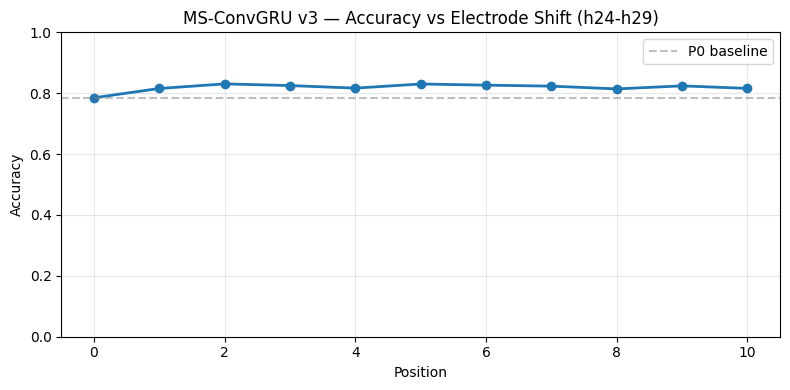

In [10]:
shift_subjects = [f"h{i}" for i in range(24, 30)]
shift_data = META[(META["subject"].isin(shift_subjects)) & (META["session"] == 0)]

s7_acc = {}
for pos in sorted(shift_data["position"].unique()):
    pos_df = shift_data[shift_data["position"] == pos]
    X_p, y_p, _ = load_and_norm(pos_df, stats=norm_stats)
    s7_acc[pos] = accuracy_score(y_p, base_predict(X_p))
    print(f"  Position {pos:2d}: {s7_acc[pos]:.4f}")

baseline = s7_acc.get(0, 0)
avg_shifted = np.mean([s7_acc[p] for p in s7_acc if p > 0])
print(f"\nP0 baseline: {baseline:.4f}, Avg shifted: {avg_shifted:.4f}, "
      f"Degradation: {(baseline - avg_shifted) * 100:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(list(s7_acc.keys()), list(s7_acc.values()), "o-", linewidth=2)
plt.axhline(y=baseline, color="gray", linestyle="--", alpha=0.5, label="P0 baseline")
plt.xlabel("Position")
plt.ylabel("Accuracy")
plt.title("MS-ConvGRU v3 — Accuracy vs Electrode Shift (h24-h29)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "msgru_v3_shift_curve.png"), dpi=150)
plt.show()

## S8: Few-Shot Calibration Analysis

In [11]:
subset_s8 = META[(META["session"] == 0) & (META["subject"].isin(TEST_SUBJECTS))]

configs = [
    ("Zero-shot",        [],     False, 0),
    ("1 rep, p0 only",   [0],    True,  7),
    ("1 rep, all pos",   [0],    False, 77),
    ("2 rep, p0 only",   [0, 1], True,  14),
    ("2 rep, all pos",   [0, 1], False, 154),
]

s8_results = {}
for label, reps, p0_only, n_trials in configs:
    cal_accs = []
    for subj in TEST_SUBJECTS:
        sdf = subset_s8[subset_s8["subject"] == subj]
        if len(reps) == 0:
            X_t, y_t, _ = load_and_norm(sdf, stats=norm_stats)
            cal_accs.append(accuracy_score(y_t, base_predict(X_t)))
            continue
        if p0_only:
            cal_df = sdf[(sdf["repetition"].isin(reps)) & (sdf["position"] == 0)]
        else:
            cal_df = sdf[sdf["repetition"].isin(reps)]
        te_df = sdf[sdf["repetition"] == 2]
        if len(cal_df) == 0 or len(te_df) == 0:
            continue
        X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
        X_t, y_t, _ = load_and_norm(te_df, stats=norm_stats)
        ft = msgru_finetune(X_c, y_c)
        cal_accs.append(accuracy_score(y_t, ft(X_t)))
    s8_results[label] = np.mean(cal_accs) if cal_accs else float("nan")
    print(f"  {label:20s}: {s8_results[label]:.4f}  (~{n_trials} trials)")

  Zero-shot           : 0.6183  (~0 trials)
  1 rep, p0 only      : 0.6272  (~7 trials)
  1 rep, all pos      : 0.8529  (~77 trials)
  2 rep, p0 only      : 0.6965  (~14 trials)
  2 rep, all pos      : 0.8824  (~154 trials)


## Latency

In [12]:
sample = X_train[:1]

def single_predict(x):
    t = torch.FloatTensor(x).to(DEVICE)
    with torch.no_grad():
        return model(t).argmax(1).cpu().numpy()

latency = measure_latency(single_predict, sample, n_runs=500)
print_latency(latency, model_name="MS-ConvGRU v3")


Latency — MS-ConvGRU v3
  Mean:   10.78 ms
  Median: 10.04 ms
  P95:    13.33 ms
  <300ms: ✓


## Summary

In [13]:
print()
print("=" * 65)
print("  MS-ConvGRU v3 -- RESULTS")
print("=" * 65)
print(f"{'Scenario':<25s} {'Zero-shot':>10s} {'Calibrated':>12s} {'Delta':>10s}")
print("-" * 65)
pairs = [
    ("S1 Ideal", zero_results.get("S1", 0), cal_results.get("S1", 0)),
    ("S2 Shift", zero_results.get("S2", 0), cal_results.get("S2", 0)),
    ("S3 Inter-subject", zero_results.get("S3", 0), cal_results.get("S3", 0)),
    ("S4 Inter-day", zero_results.get("S4", 0), cal_results.get("S4", 0)),
    ("S5 Fatigue", zero_results.get("S5", 0), cal_results.get("S5", 0)),
]
for name, zs, cal in pairs:
    d = cal - zs
    check = " ✓" if cal >= 0.85 else ""
    print(f"{name:<25s} {zs*100:>9.2f}% {cal*100:>11.2f}%{check} {d*100:>+9.2f}%")
print(f"{'S6 Combined':<25s} {s6_zs*100:>9.2f}% {s6_cal*100:>11.2f}% {(s6_cal-s6_zs)*100:>+9.2f}%")
print(f"{'S7 Gradual (avg shift)':<25s} {avg_shifted*100:>9.2f}% {'--':>12s} {'--':>10s}")
for label, val in s8_results.items():
    if label == "Zero-shot":
        continue
    print(f"{'S8 ' + label:<25s} {'--':>10s} {val*100:>11.2f}% {'--':>10s}")
print("-" * 65)
print(f"Parameters:  {total_params:,}")
print(f"Latency p95: {latency['p95_ms']:.2f} ms")
print("=" * 65)


  MS-ConvGRU v3 -- RESULTS
Scenario                   Zero-shot   Calibrated      Delta
-----------------------------------------------------------------
S1 Ideal                      63.85%       84.59%    +20.73%
S2 Shift                      61.67%       84.50%    +22.84%
S3 Inter-subject              61.87%       88.24% ✓    +26.37%
S4 Inter-day                  72.28%       86.20% ✓    +13.91%
S5 Fatigue                    80.23%       88.08% ✓     +7.85%
S6 Combined                   61.67%       88.82%    +27.15%
S7 Gradual (avg shift)        82.22%           --         --
S8 1 rep, p0 only                 --       62.72%         --
S8 1 rep, all pos                 --       85.29%         --
S8 2 rep, p0 only                 --       69.65%         --
S8 2 rep, all pos                 --       88.24%         --
-----------------------------------------------------------------
Parameters:  125,059
Latency p95: 13.33 ms


## Save

In [14]:
print("Model saved at:", MODELS_DIR / "msgru_v3.pt")
print("Done.")

Model saved at: /Users/erdiantiwigaputriandini/Documents/Kuliah/Tugas Akhir/04. TA/02. Code/Tugas-Akhir/results/models/msgru_v3.pt
Done.
